In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

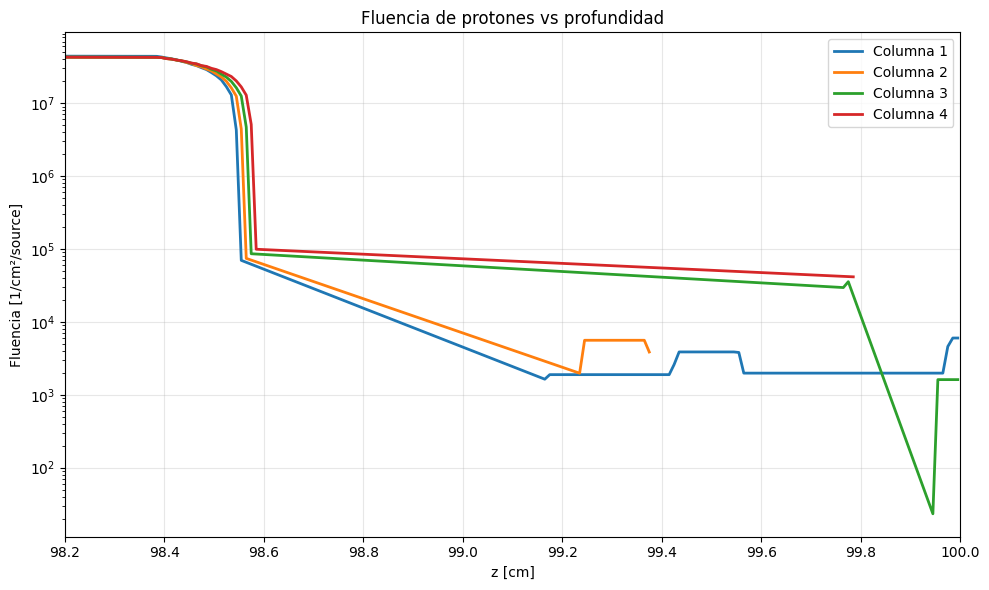

In [3]:
archivos_flujo = {
    "Columna 1": "../out/flujo_z_col1.out",
    "Columna 2": "../out/flujo_z_col2.out",
    "Columna 3": "../out/flujo_z_col3.out",
    "Columna 4": "../out/flujo_z_col4.out",
}

def leer_flujo(ruta):
    z = []
    flujo = []
    leyendo = False

    with open(ruta, "r") as f:
        for linea in f:
            if "#  z-lower" in linea and "z-upper" in linea:
                leyendo = True
                continue

            if leyendo and "#   sum over" in linea:
                break

            if leyendo:
                datos = linea.split()

                if len(datos) >= 4:
                    try:
                        z_lower = float(datos[0])
                        z_upper = float(datos[1])
                        valor = float(datos[2])

                        z.append((z_lower + z_upper) / 2)
                        flujo.append(valor)

                    except ValueError:
                        pass

    return np.array(z), np.array(flujo)


plt.figure(figsize=(10, 6))

for nombre, archivo in archivos_flujo.items():
    z, flujo = leer_flujo(archivo)

    mask = flujo > 0

    plt.plot(
        z[mask],
        flujo[mask],
        linewidth=2,
        label=nombre
    )

plt.xlabel("z [cm]")
plt.ylabel("Fluencia [1/cm²/source]")
plt.title("Fluencia de protones vs profundidad")
plt.xlim(98.2, 100)
plt.yscale("log")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

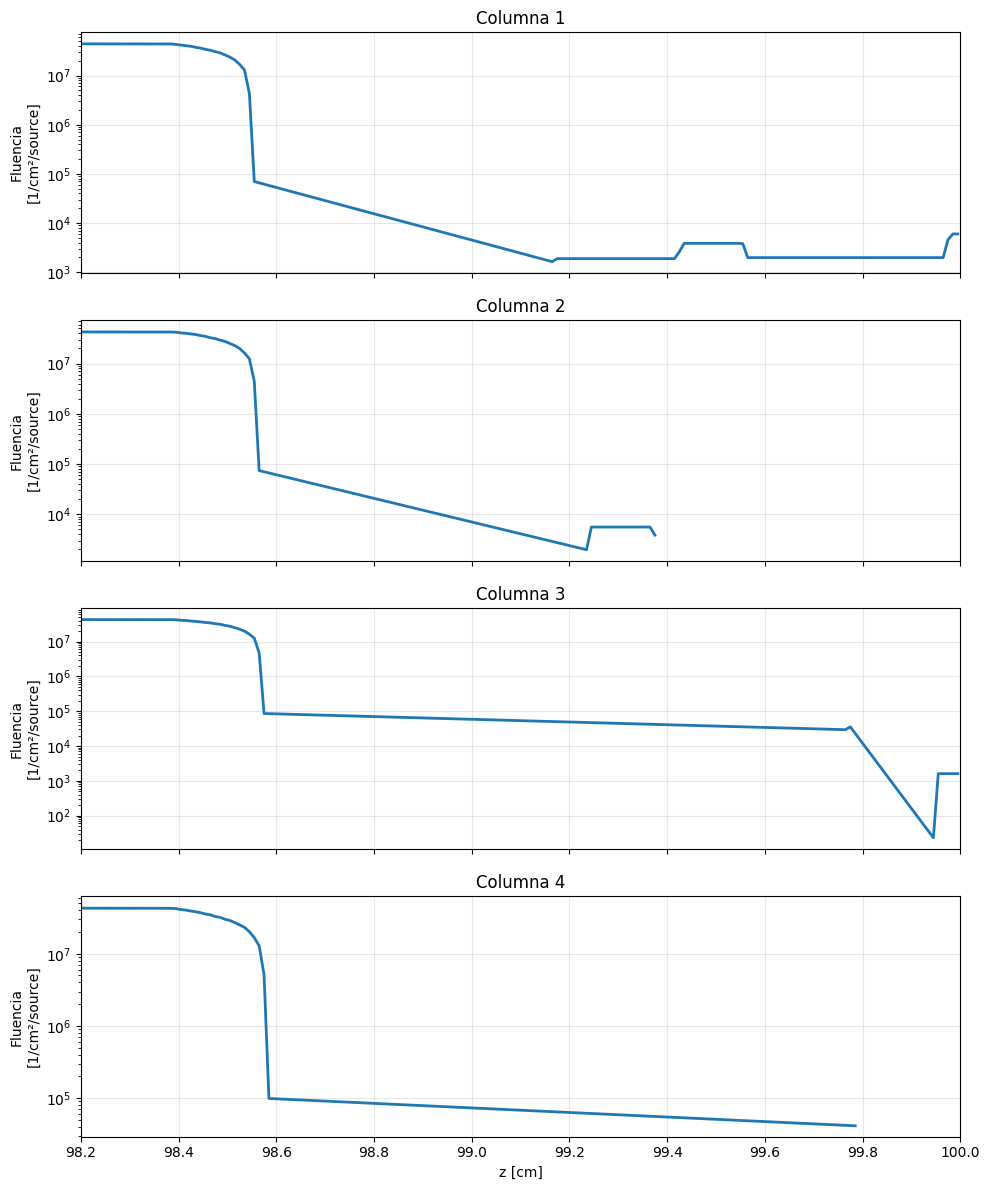

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for ax, (nombre, archivo) in zip(axes, archivos_flujo.items()):
    z, flujo = leer_flujo(archivo)

    mask = flujo > 0

    ax.plot(z[mask], flujo[mask], linewidth=2)
    ax.set_xlim(98.2, 100)
    ax.set_yscale("log")
    ax.set_ylabel("Fluencia\n[1/cm²/source]")
    ax.set_title(nombre)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("z [cm]")

plt.tight_layout()
plt.show()